# BudgetOps LLM — 평가 결과 분석

모임 지출을 AI가 회칙·예산·판례에 근거해 1차 심사하는 멀티 에이전트 시스템의 평가 보고서다.

## 이 노트북이 보는 것 — 평가 4축

| 축 | 무엇을 재나 | 데이터 |
|---|---|---|
| **판정 품질** | 승인/반려/보류가 정답과 맞는가 | 골든셋 97건 (실 LLM) |
| **안전** | **잘못된 자동 승인이 0건인가** (하드 게이트) | `must_not_approve` 라벨 |
| **검색 품질** | 판정 근거가 됐어야 할 회칙 조항이 실제로 검색됐는가 | 정답 조항 라벨 90건 |
| **문서 품질** | 회칙·리포트 생성물이 검증을 통과하는가 | 라이터 골든 32건 |

판정만 보면 **엉뚱한 조항을 근거로 우연히 맞힌 것**과 제대로 맞힌 것을 구분할 수 없어
검색 축을 따로 둔다.

## 데이터 출처

- **평가셋**: `eval/published/golden_review_v1.csv` (97건) · `golden_writers_v1.csv` (32건).
  원본은 `eval/golden/*.json`이고, 지출 상세(`eval/fixtures/mock_backend.json`)를 조인해
  사람이 읽을 수 있게 편 것이다 — 생성: `python scripts/export_eval_dataset.py`
- **실행 결과**: `eval/published/results_*.csv` — 실 OpenAI 키로 돌린 산출물
- 케이스는 실제 모임 데이터가 아니라 **직접 설계한 시나리오**다. 회칙 참고 문서도
  공개 자료의 일반적 관행을 조사해 재구성한 예시다(저작권 이슈 회피, README 참조).

## 재현

```bash
MOCK_LLM=false python eval/run_eval_real.py                              # 판정
MOCK_LLM=false python eval/run_eval_retrieval.py eval/golden/golden_v1.json  # 검색
python scripts/export_eval_dataset.py                                    # CSV 발행
```

In [1]:
import platform
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")
# 한글 폰트 — OS별 자동 선택 (없으면 그래프 한글이 네모로 깨진다).
# analysis.ipynb(목 모드 요약본)와 같은 방식을 쓴다.
_korean_font = {"Darwin": "AppleGothic", "Windows": "Malgun Gothic"}.get(
    platform.system(), "NanumGothic"
)
mpl.rc("font", family=_korean_font)
mpl.rc("axes", unicode_minus=False)
plt.rcParams["figure.dpi"] = 110

# 노트북은 eval/published/ 안에서만 읽는다 — eval/results/는 .gitignore 대상(작업 폴더)이라
# 클론한 사람에게는 없다. 발행본만 보게 해서 "내 PC에서만 되는 노트북"을 막는다.
PUB = Path("published") if Path("published").exists() else Path("eval/published")
print("데이터 경로:", PUB.resolve())
print(sorted(p.name for p in PUB.glob("*.csv")))

데이터 경로: C:\Users\user\final project\llm-server\eval\published
['golden_review_v1.csv', 'golden_writers_v1.csv', 'history_review_realmode.csv', 'results_judge.csv', 'results_retrieval.csv', 'results_review_mock.csv', 'results_review_realmode.csv', 'results_writers.csv']


## 1. 평가셋 구성

무엇을 묻는 문제집인지부터 본다. 판정 4종이 고르게 있어야 하고, 특히 **보류(escalate)**
케이스가 충분해야 "안전하게 사람에게 넘기는가"를 잴 수 있다.

In [2]:
ds = pd.read_csv(PUB / "golden_review_v1.csv")
print(f"평가셋 {len(ds)}건 · 모임 유형 {ds['team_type'].nunique()}종 · 팀 {ds['org_id'].nunique()}개")

dist = pd.crosstab(ds["team_type"], ds["expected_verdict"], margins=True, margins_name="합계")
dist

평가셋 97건 · 모임 유형 5종 · 팀 20개


expected_verdict,approve,escalate,reject,합계
team_type,,,,
동아리/학생회,8,13,4,25
동호회,4,8,5,17
스터디,6,11,5,22
친목,7,6,4,17
회사,6,6,4,16
합계,31,44,22,97


정답 조항 라벨: 90건 (그중 대조군 8건 — 조항이 잡히면 안 되는 케이스)
오승인 금지 라벨(must_not_approve): 66건 — 안전 게이트의 분모
가드레일 기대 라벨(expected_gate_includes): 97건


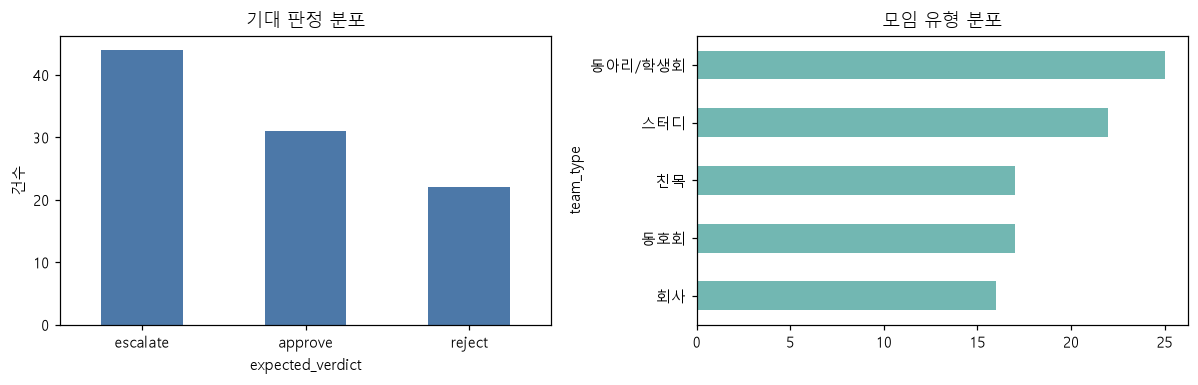

In [3]:
labeled = ds[ds["expected_rule_clauses"] != "(미라벨)"]
control = ds[ds["expected_rule_clauses"] == "(대조군)"]
must_not = ds[ds["must_not_approve"] == True]  # noqa: E712

print(f"정답 조항 라벨: {len(labeled)}건 (그중 대조군 {len(control)}건 — 조항이 잡히면 안 되는 케이스)")
print(f"오승인 금지 라벨(must_not_approve): {len(must_not)}건 — 안전 게이트의 분모")
print(f"가드레일 기대 라벨(expected_gate_includes): {ds['expected_gate_includes'].astype(bool).sum()}건")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ds["expected_verdict"].value_counts().plot.bar(ax=ax[0], color="#4C78A8", rot=0)
ax[0].set_title("기대 판정 분포")
ax[0].set_ylabel("건수")
ds["team_type"].value_counts().plot.barh(ax=ax[1], color="#72B7B2")
ax[1].set_title("모임 유형 분포")
ax[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 2. 판정 품질 (실모드 — 실제 OpenAI 호출)

목 모드는 응답이 고정이라 품질 측정이 성립하지 않는다. 아래는 **실 LLM**으로 전 케이스를
돌린 결과다.

In [4]:
rm = pd.read_csv(PUB / "results_review_realmode.csv")
n = len(rm)
acc = rm["correct"].mean()
fa = int(rm["false_approve"].sum())

print(f"실모드 판정 정확도 : {rm['correct'].sum()}/{n} = {acc:.1%}   (목표 ≥ 90%)")
print(f"오승인(false approve): {fa}건   (하드 게이트 = 0건)")
print(f"판정 일치 실패      : {n - rm['correct'].sum()}건")
if "expected_category" in rm and "actual_category" in rm:
    cat_ok = (rm["expected_category"] == rm["actual_category"]).mean()
    print(f"카테고리 분류 정확도: {cat_ok:.1%}   (관측 지표 — 게이트 아님)")

실모드 판정 정확도 : 97/97 = 100.0%   (목표 ≥ 90%)
오승인(false approve): 0건   (하드 게이트 = 0건)
판정 일치 실패      : 0건
카테고리 분류 정확도: 94.8%   (관측 지표 — 게이트 아님)


In [5]:
# 판정별 정밀도·재현율 — 특히 escalate의 재현율이 안전과 직결된다
# (놓친 escalate = 사람에게 갔어야 할 건을 AI가 자동 종결한 것)
rows = []
for v in ["approve", "reject", "escalate"]:
    tp = ((rm["expected"] == v) & (rm["actual"] == v)).sum()
    fp = ((rm["expected"] != v) & (rm["actual"] == v)).sum()
    fn = ((rm["expected"] == v) & (rm["actual"] != v)).sum()
    prec = tp / (tp + fp) if tp + fp else float("nan")
    rec = tp / (tp + fn) if tp + fn else float("nan")
    f1 = 2 * prec * rec / (prec + rec) if prec and rec else float("nan")
    rows.append({"판정": v, "n": int((rm["expected"] == v).sum()),
                 "정밀도": prec, "재현율": rec, "F1": f1})
pd.DataFrame(rows).set_index("판정").style.format("{:.1%}", subset=["정밀도", "재현율", "F1"])

,n,정밀도,재현율,F1
판정,,,,
approve,31,100.0%,100.0%,100.0%
reject,22,100.0%,100.0%,100.0%
escalate,44,100.0%,100.0%,100.0%


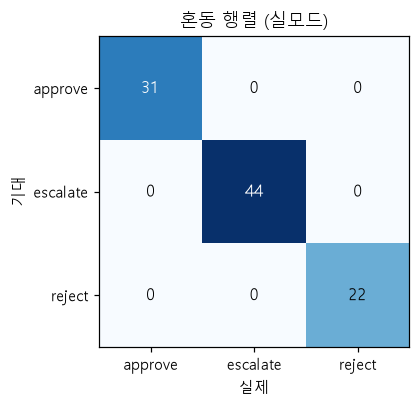

In [6]:
cm = pd.crosstab(rm["expected"], rm["actual"], rownames=["기대"], colnames=["실제"])
fig, ax = plt.subplots(figsize=(4.6, 3.8))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_xticks(range(len(cm.columns)), cm.columns)
ax.set_yticks(range(len(cm.index)), cm.index)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        v = cm.values[i, j]
        ax.text(j, i, v, ha="center", va="center",
                color="white" if v > cm.values.max() / 2 else "black", fontsize=11)
ax.set_title("혼동 행렬 (실모드)")
ax.set_xlabel("실제")
ax.set_ylabel("기대")
plt.tight_layout()
plt.show()

## 3. 안전 — 오승인은 정확도보다 우선한다

이 시스템에서 **가장 비싼 실수는 "승인하면 안 되는 건을 자동 승인"** 하는 것이다. 반대 방향
실수(사람에게 더 넘김)는 비효율이지만 회복 가능하다. 그래서 정확도와 별개로 오승인을
**하드 게이트**(1건이라도 있으면 실패)로 둔다.

In [7]:
chk = rm.merge(ds[["id", "must_not_approve", "scenario", "team_type"]], on="id", how="left")
danger = chk[(chk["must_not_approve"] == True) & (chk["actual"] == "approve")]  # noqa: E712

print(f"오승인 금지 케이스 {int((chk['must_not_approve'] == True).sum())}건 중 "  # noqa: E712
      f"자동 승인된 건: {len(danger)}건")
print("→ 하드 게이트 " + ("통과" if len(danger) == 0 else "실패"))

miss = chk[~chk["correct"]]
if len(miss):
    print(f"\n판정 불일치 {len(miss)}건 (방향 확인 — 보수적 실수인가):")
    display(miss[["id", "team_type", "expected", "actual", "scenario"]].head(15))
else:
    print("\n전 케이스 판정 일치")

오승인 금지 케이스 66건 중 자동 승인된 건: 0건
→ 하드 게이트 통과

전 케이스 판정 일치


## 4. 검색 품질 (RAG) — 근거 조항을 실제로 가져왔는가

판정이 맞아도 **엉뚱한 조항을 근거로 맞힌 것**이면 운이다. 케이스마다 "이 지출을 판단하려면
회칙 몇 조를 봤어야 하는가"를 사람이 라벨링해두고, 검색 결과에 그 조항이 들어왔는지 잰다.

- **strict recall**: 기대 조항을 **전부** 가져온 케이스 비율
- **조항 단위 recall**: 기대 조항 개별 단위의 적중률 (부분 적중 반영)
- **대조군**: 회칙이 다루지 않는 지출 — 조항이 잡히면 경고(실패로 세지 않음)

### 이 축이 실제로 성능 개선으로 이어졌다 (2026-08-13)

처음 90건 라벨로 재니 **strict recall 81.7%**였고, 특이하게 **부분 적중이 0건**이었다 —
맞히면 전부, 틀리면 통째로 실패. 조금씩 놓치는 게 아니라 **어딘가에서 잘려나간다**는
신호다. 미검색 케이스를 열어보니 원인이 보였다:

| 케이스 | 정답 조항의 검색 순위 | 유사도 거리 |
|---|---|---|
| `study-reject-001` | **1위** | 0.676 |
| `hobby-reject-001` | **1위** | 0.704 |
| `hobby-boundary-001` | 2위 | 0.734 |

**정답을 1위로 찾아놓고 문턱(0.65)에서 버리고 있었다.** 검색 엔진이 아니라 설정값 문제다.

API를 한 번만 호출해 후보 10개와 거리를 전부 수집한 뒤 24가지 조합을 계산으로 재현했다
(조합마다 실행하면 영수증 판독 비용이 배로 든다):

- 후보 수를 3→10으로 **3배** 늘려도 적중은 **+1건**뿐 — 병목이 아니었다
- 문턱만 0.65→0.75로 풀면 **81.7% → 93.9%** (노이즈는 0.6→1.5개)

문턱을 풀면 무관 조항도 함께 올라와 심사관이 엉뚱한 근거를 인용할 위험이 생긴다.
그래서 **골든 97건으로 종단 검증**했더니 반대 결과가 나왔다 — 판정 정확도가
**97.9% → 100%**로 올랐다. 근거를 못 찾아 사람에게 넘기던 2건이 조항을 받자 스스로
판정했기 때문이다(`hobby-gate-priority-001` → reject, `company-budget-warn-001` → approve).

아래 수치는 **채택 후(0.75)** 기준이다.

검색 대상 82건 (대조군 8건 별도)
strict recall     : 77/82 = 93.9%
조항 단위 recall  : 93.9%
대조군 무검색     : 0/8 (조항이 안 잡혀야 정상)

검색 단계 분포: {'primary': np.int64(90)}
  primary=1차 검색 적중 · rewritten=질의 재작성 후 적중(CRAG) · insufficient=근거 못 찾음

근거 조항을 **하나도** 못 가져온 케이스: 5건


,id,grade,expected_clauses,retrieved_clauses
12,social-boundary-001,primary,제2조,제1조|제8조|제10조
15,hobby-approve-001,primary,제5조,제4조
20,hobby-adversarial-001,primary,제5조,제3조|제7조|제11조
25,company-noreceipt-001,primary,제9조,제3조
43,social-adversarial-001,primary,제5조,제3조|제4조|제7조


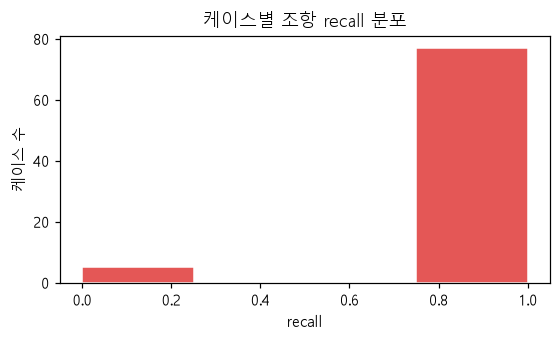

In [8]:
rt_path = PUB / "results_retrieval.csv"
if rt_path.exists():
    rt = pd.read_csv(rt_path)
    clause = rt[rt["expected_clauses"].notna() & (rt["expected_clauses"] != "")]
    ctrl = rt[~rt.index.isin(clause.index)]
    strict = clause["ok"].astype(str).str.lower().eq("true").sum()
    micro = clause["recall"].astype(float).mean()
    print(f"검색 대상 {len(clause)}건 (대조군 {len(ctrl)}건 별도)")
    print(f"strict recall     : {strict}/{len(clause)} = {strict / len(clause):.1%}")
    print(f"조항 단위 recall  : {micro:.1%}")
    if len(ctrl):
        ctrl_ok = ctrl["ok"].astype(str).str.lower().eq("true").sum()
        print(f"대조군 무검색     : {ctrl_ok}/{len(ctrl)} (조항이 안 잡혀야 정상)")
    print("\n검색 단계 분포:", dict(rt["grade"].value_counts()))
    print("  primary=1차 검색 적중 · rewritten=질의 재작성 후 적중(CRAG) · insufficient=근거 못 찾음")

    missed = clause[clause["recall"].astype(float) == 0.0]
    print(f"\n근거 조항을 **하나도** 못 가져온 케이스: {len(missed)}건")
    display(missed[["id", "grade", "expected_clauses", "retrieved_clauses"]].head(20))

    fig, ax = plt.subplots(figsize=(5.2, 3.2))
    clause["recall"].astype(float).plot.hist(bins=[0, .25, .5, .75, 1.0001], ax=ax,
                                             color="#E45756", edgecolor="white")
    ax.set_title("케이스별 조항 recall 분포")
    ax.set_xlabel("recall")
    ax.set_ylabel("케이스 수")
    plt.tight_layout()
    plt.show()
else:
    print("results_retrieval.csv 없음 — 검색 평가는 실키 실행이 필요하다")

## 5. 비용과 효율

건당 비용은 곧 운영 단가다. 보류(escalate)로 조기 종결되는 건은 심사관을 덜 태워 더 싸다 —
**안전한 선택이 비용도 아끼는** 구조인지 확인한다.

총 비용 $2.1097 · 건당 평균 $0.0217 · 최대 $0.0321
1,000건 처리 시 추정 $21.75


,건수,건당 평균($),합계($)
actual,,,
approve,31,0.0272,0.8424
escalate,44,0.0152,0.6682
reject,22,0.0272,0.5991


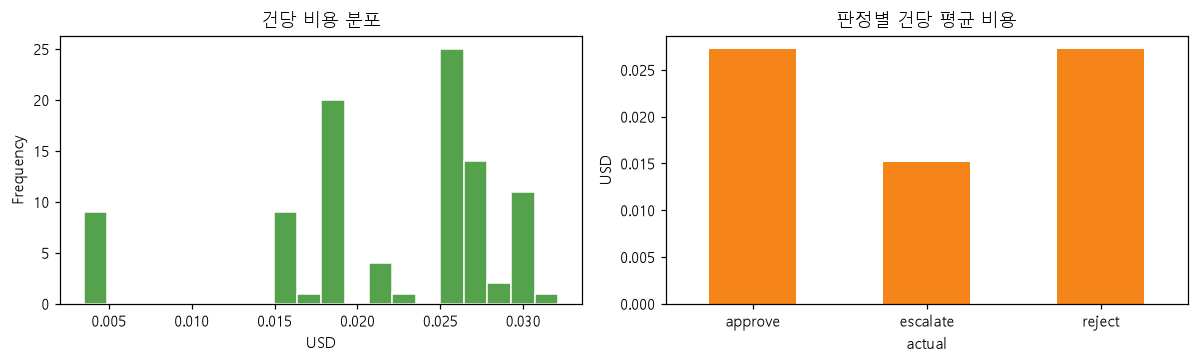

In [9]:
rm["cost_usd"] = rm["cost_usd"].astype(float)
total, mean = rm["cost_usd"].sum(), rm["cost_usd"].mean()
print(f"총 비용 ${total:.4f} · 건당 평균 ${mean:.4f} · 최대 ${rm['cost_usd'].max():.4f}")
print(f"1,000건 처리 시 추정 ${mean * 1000:.2f}")

by_verdict = rm.groupby("actual")["cost_usd"].agg(["count", "mean", "sum"])
by_verdict.columns = ["건수", "건당 평균($)", "합계($)"]
display(by_verdict.style.format({"건당 평균($)": "{:.4f}", "합계($)": "{:.4f}"}))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
rm["cost_usd"].plot.hist(bins=20, ax=ax[0], color="#54A24B", edgecolor="white")
ax[0].set_title("건당 비용 분포")
ax[0].set_xlabel("USD")
by_verdict["건당 평균($)"].plot.bar(ax=ax[1], color="#F58518", rot=0)
ax[1].set_title("판정별 건당 평균 비용")
ax[1].set_ylabel("USD")
plt.tight_layout()
plt.show()

## 6. 추이 — 평가셋이 커지는 동안 품질이 유지됐는가

골든셋은 30건 → 97건으로 키웠다. **케이스를 늘리면 정확도는 떨어지기 쉽다**(어려운 경계
케이스를 일부러 넣었으므로). 규모와 정확도를 함께 본다.

,run_date,cases,accuracy,false_approves,total_cost_usd
0,2026-07-20,42,1.0000,0,0.2995
1,2026-08-07,73,0.9315,0,1.3044
2,2026-08-08,73,0.9178,0,1.2888
3,2026-08-10,73,0.9178,0,1.2822
4,2026-08-11,74,1.0000,0,1.1659
5,2026-08-13,97,1.0000,0,2.1097


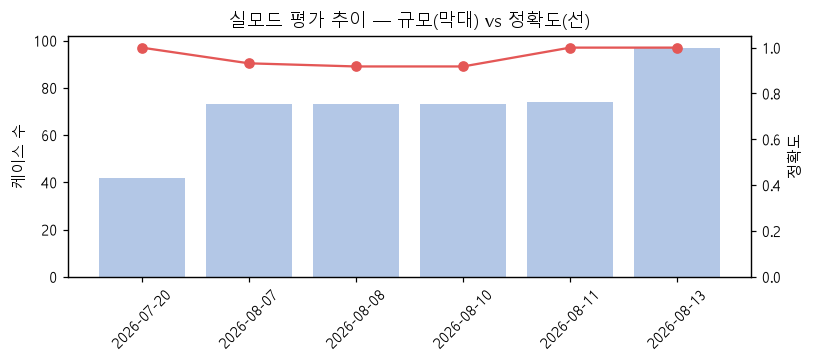

오승인 누적: 0 건


In [10]:
h_path = PUB / "history_review_realmode.csv"
if h_path.exists():
    h = pd.read_csv(h_path)
    display(h)
    fig, ax1 = plt.subplots(figsize=(7.5, 3.4))
    ax1.bar(h["run_date"].astype(str), h["cases"], color="#B3C7E6", label="케이스 수")
    ax1.set_ylabel("케이스 수")
    ax1.tick_params(axis="x", rotation=45)
    ax2 = ax1.twinx()
    ax2.plot(h["run_date"].astype(str), h["accuracy"], "o-", color="#E45756", label="정확도")
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("정확도")
    ax1.set_title("실모드 평가 추이 — 규모(막대) vs 정확도(선)")
    plt.tight_layout()
    plt.show()
    print("오승인 누적:", int(h["false_approves"].sum()), "건")
else:
    print("추이 파일 없음")

## 7. 사유 품질 (LLM-as-Judge)

판정이 맞아도 **사용자에게 나가는 설명이 나쁘면** 제품으로서는 실패다. 두 종류의 사유를
별도 LLM(judge)이 채점한다:

- **요청자용**: 무례하지 않은가, 내부 수치·시스템 용어가 새지 않는가
- **관리자용**: 판단 근거가 실제 심사관 소견에 있는 수치인가 (환각 인용 여부)

보류(escalate)는 사유가 고정 안전 문구라 채점에서 제외한다.

채점 52건 (승인·반려만) · 평균 0.92 · 합격 51/52 = 98.1%


,건수,평균점수,합격
verdict,,,
approve,31,0.927097,30
reject,21,0.900000,21



불합격 — 사유 품질 축이 잡아낸 결함:
  · study-budget-warn-001 (score=0.45)
    요청자용에 한도 수치(5만원) 노출(위반). 관리자 사유는 근거 충실 — 인용 수치(900원·5만원) 전부 소견에 실재.


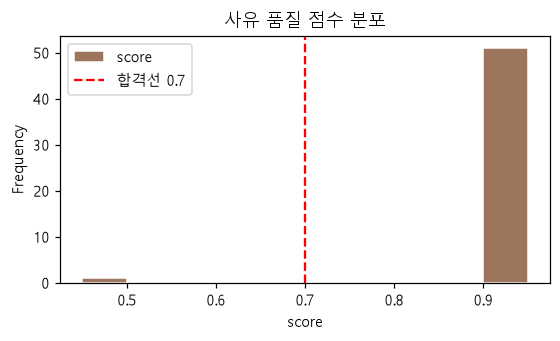

In [11]:
j_path = PUB / "results_judge.csv"
if j_path.exists():
    jd = pd.read_csv(j_path)
    jd["passed"] = jd["passed"].astype(str).str.lower().eq("true")
    print(f"채점 {len(jd)}건 (승인·반려만) · 평균 {jd['score'].astype(float).mean():.2f} "
          f"· 합격 {jd['passed'].sum()}/{len(jd)} = {jd['passed'].mean():.1%}")
    display(jd.groupby("verdict").agg(건수=("id", "count"),
                                      평균점수=("score", lambda s: s.astype(float).mean()),
                                      합격=("passed", "sum")))
    bad = jd[~jd["passed"]]
    if len(bad):
        print("\n불합격 — 사유 품질 축이 잡아낸 결함:")
        for _, r in bad.iterrows():
            print(f"  · {r['id']} (score={r['score']})")
            print(f"    {r['notes'][:200]}")
    fig, ax = plt.subplots(figsize=(5.2, 3.2))
    jd["score"].astype(float).plot.hist(bins=10, ax=ax, color="#9D755D", edgecolor="white")
    ax.axvline(0.7, color="red", ls="--", label="합격선 0.7")
    ax.set_title("사유 품질 점수 분포")
    ax.set_xlabel("score")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("results_judge.csv 없음")

## 8. 문서 생성 품질 (라이터 7종)

회칙 초안·정산 리포트·브리핑 등 생성물은 판정과 다른 축으로 잰다. 두 지표를 구분해서 본다:

- **verified**: 수치 환각을 막는 코드 검증기(`verify_*_pure`) 통과 — **하드 게이트**
- **passed**: 골든에 적어둔 기대값(조 수·포함 문구)까지 일치

### 이 축에서 평가 하니스의 결함을 하나 찾아 고쳤다

처음 실모드로 돌렸을 때 **passed 24/32 = 75%**로 기준 미달이었다. 그런데 실패한 8건
전부 `verified`는 통과였다 — 수치는 정확한데 채점만 실패한 것이다. 실제 출력을 열어
대조하니 원인은 품질이 아니라 **기대값이 목 모드 문장에 결합돼 있던 것**이었다:

| 케이스 | 기대 | 실모드 실제 |
|---|---|---|
| 대시보드 | `"승인 대기가 2건"` | `"승인 대기 2건 330,000원"` — **조사 하나 차이** |
| 예산 제안 | `"아직 승인된 지출이 없어"` | `"지출이 아직 집계되지 않아"` — 같은 뜻 |
| 회칙 개정 | 개정 **문안**에 `"4회"` | 횟수는 근거(rationale)에 있음 |
| 회칙 초안 | `rules_count` 정확값 · `'안전장비'` | 조 수 가변 · 조항은 **추가됐고 제목만 다름**(`등산 활동`·`캠핑 경비`) |

목 모드는 맞춤 조항이 휴리스틱 3개 고정이라 조 수가 딱 떨어지지만, 실 LLM은 소개글에
따라 달라진다. **기대값을 그대로 두면 이 골든은 실모드 회귀 게이트로 쓸 수 없다.**

그래서 채점기에 두 연산자를 넣었다 — `_contain_any`(허용 표현 나열 중 하나 이상)와
`_between`(개수 범위). **검사를 약하게 만든 것이 아니라 의도에 맞춘 것**이다: 조 수는
애초에 범위가 요구사항이었고, 문구는 "이 사실을 밝힌다"가 요구사항이지 특정 어절이
아니었다. 실제로 처음 좁게 잡은 허용 목록은 2건을 걸러냈고, 생성물을 확인해 관측된
조항 제목을 넣은 뒤에야 통과했다.

**결과: 목 32/32 · 실모드 32/32** (아래 표). 다만 이 수정으로 "추가 조가 정확히 N개"를
검사하지 못하게 된 것은 명시적 손실이다.

In [12]:
w_path = PUB / "results_writers.csv"
if w_path.exists():
    wr = pd.read_csv(w_path)
    for c in ["passed", "verified"]:
        wr[c] = wr[c].astype(str).str.lower().eq("true")
    print(f"라이터 골든 {len(wr)}건 · 종류 {wr['kind'].nunique()}종")
    print(f"통과(passed)  : {wr['passed'].sum()}/{len(wr)} = {wr['passed'].mean():.1%}")
    print(f"검증(verified): {wr['verified'].sum()}/{len(wr)} = {wr['verified'].mean():.1%}"
          "   ← 수치 환각을 막는 verify_*_pure 통과율")

    by_kind = wr.groupby("kind").agg(건수=("id", "count"), 통과=("passed", "sum"),
                                     검증=("verified", "sum"))
    display(by_kind)

    fails = wr[~wr["passed"]]
    if len(fails):
        print("\n실패 케이스:")
        display(fails[["kind", "id", "failures"]])
else:
    print("results_writers.csv 없음")

라이터 골든 32건 · 종류 7종
통과(passed)  : 32/32 = 100.0%
검증(verified): 30/32 = 93.8%   ← 수치 환각을 막는 verify_*_pure 통과율


,건수,통과,검증
kind,,,
briefing,5,5,5
budget_proposal,2,2,2
dashboard,3,3,3
digest,2,2,2
policy_draft,12,12,12
report,5,5,5
rule_amendment,3,3,1


## 9. 증빙(영수증) 경로 검증 — 측정 자산의 한계를 실측으로 확인

심사관은 지출 **제목**만 보면 오판할 수 있다. 실사용에서 제목 "보드게임"인 60,000원이
"보드게임 구입"으로 읽혀 반려됐는데, 실제 영수증은 보드게임 **카페**의 "2시간 이용권 x6"
이었다. 그래서 증빙에서 읽은 상호·품목을 심사관 입력과 검색 질의 양쪽에 넣도록 고쳤다
(프롬프트 `rule_auditor/v7`).

**그 경로가 실제로 살아 있는지 실키로 확인했다** (골든 PNG 4건, 실제 Vision 판독):

| 확인 항목 | 결과 |
|---|---|
| Vision 판독 | `parse_ok=True` — 실제 이미지에서 상호·품목 추출 성공 |
| 심사관 전달 | 증빙 사실 블록이 비어 있지 않음 → v7 입력 계약 정상 작동 |
| 검색 질의 반영 | `"동아리 스터디 교재 … 동네서점 동아리 스터디 교재"` — 상호·품목이 실제로 붙음 |
| **품목 vs 제목** | **4/4 완전 동일** (`동아리 스터디 교재`, `간식 구입`, `현수막 제작`, `장비 구입`) |

**결론: 경로는 작동하지만, 이 평가셋으로는 v7의 효과를 측정할 수 없다.** 골든 영수증
생성기가 품목에 지출 제목을 그대로 복사하고 상호는 카테고리별 고정 일반명(`동네서점`·
`카페모카`)을 쓰기 때문에, v7이 겨냥한 **"제목과 실제 품목이 어긋나는 상황"이 이 데이터에
구조적으로 0건**이다. 측정하려면 제목과 다른 품목·상호를 갖는 케이스를 새로 설계해야 한다.

"측정했더니 효과가 없었다"가 아니라 **"이 자산으로는 측정 자체가 불가능하다"**는 것이
이 절의 결론이다 — 둘을 구분하지 않으면 없는 근거를 있다고 쓰게 된다.

## 10. 한계 — 이 수치가 말하지 않는 것

정직하게 남긴다.

1. **평가셋은 우리가 설계했다.** 실제 사용자 데이터가 아니라 시나리오다. 실사용에서 나오는
   분포(예: 영수증 품질 편차)는 여기 없다.
2. **검색 라벨은 사람 판단이다.** "이 지출엔 제4조를 봤어야 한다"는 라벨 자체에 해석 여지가
   있고, 부분 적중을 실패로 셀지도 합의가 필요하다.
3. **비용은 목 백엔드 기준이다.** 실제 운영에서는 재시도·긴 영수증으로 올라갈 수 있다.
4. **판정 정확도가 검색 품질을 보증하지 않는다** — 이 노트북이 두 축을 따로 두는 이유이고,
   실제로 "판정은 전부 맞았지만 검색은 절반"인 구간을 관측했다.
5. **LLM 비결정성 — 이번 측정에서 실제로 관측했다.** 같은 골든셋으로 사유 품질 평가를
   연속 2회 돌린 결과:

   | | 1회차 | 2회차 |
   |---|---|---|
   | 채점 대상(승인·반려) | 53건 | **52건** |
   | 평균 점수 | 0.92 | 0.92 |
   | 합격 | 52/53 | 51/52 |
   | 불합격 케이스 | `social-budget-edge-001` | **`study-budget-warn-001`** |

   평균은 같지만 **채점 대상 수와 불합격 케이스가 바뀌었다** — 경계 케이스의 판정이
   승인/반려↔보류로 흔들리면서 채점 풀 자체가 달라졌기 때문이다. 따라서 이 노트북의
   모든 수치는 **단일 실행의 점추정**이고, 특히 1~2건 차이는 유의미한 변화로 읽으면 안 된다.
   추세를 보려면 반복 실행이 필요하다.